## Libor Market model

Forward rates $L_i (t)$ compounded over periods $ [T_i, T_{i+1}]$ evolves as: $dL_i (t)  = \mu (t)dt + \sigma_i (t)L_i (t) dW_i(t)$

$\sigma_i (t)$: Volatility of $L_i (t)$; 
$dW_i(t)$: Brownian motion (correlated across i);
$\mu_i(t)$: drift term, depends on no-arbitrage condition (complicated, but zero under terminal measure)

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# Time and tenor settings
T = 10.0                # Total horizon in years
n_periods = 20          # Number of forward rates (e.g., semiannual for 10 years)
dt = 0.01               # Simulation time step
n_steps = int(T / dt)
times = np.linspace(0, T, n_steps)
tenors = np.linspace(0.5, T, n_periods)

# Initial forward curve (flat 4% for example)
L0 = 0.04 * np.ones(n_periods)

##### Volatility and Correlation Structures

In [8]:
# Flat volatility structure
sigma = 0.2  # 20% vol
vols = sigma * np.ones(n_periods)

# Correlation matrix (exponential decay)
def exponential_corr(n, rho):
    corr = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            corr[i, j] = rho ** abs(i - j)
    return corr

rho = 0.9
corr_matrix = exponential_corr(n_periods, rho)

# Cholesky decomposition
L_chol = np.linalg.cholesky(corr_matrix)

##### Simulate Libor rates under terminal measures

In [10]:
n_paths = 100
L = np.zeros((n_paths, n_steps, n_periods))
L[:, 0, :] = L0

for path in range(n_paths):
    for t_idx in range(1, n_steps):
        dtau = dt
        Z = np.random.normal(size=n_periods)
        dW = L_chol @ Z * np.sqrt(dtau)

        for i in range(n_periods):
            L_prev = L[path, t_idx-1, i]
            dL = vols[i] * L_prev * dW[i]
            L[path, t_idx, i] = max(L_prev + dL, 0)  # ensure positive rate

##### Plot

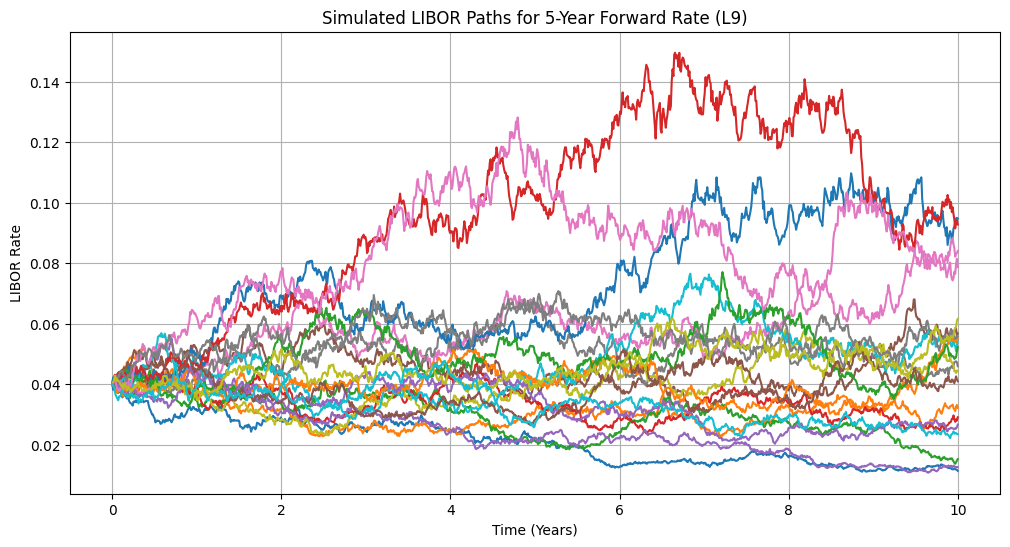

In [11]:
# Plot LIBOR paths for 5-year rate (index = 9 for T=5 if semiannual)
libor_index = 9
plt.figure(figsize=(12, 6))
for i in range(20):
    plt.plot(times, L[i, :, libor_index])
plt.title('Simulated LIBOR Paths for 5-Year Forward Rate (L9)')
plt.xlabel('Time (Years)')
plt.ylabel('LIBOR Rate')
plt.grid(True)
plt.show()

##### LIBOR Market Model (LMM) Monte Carlo Pricing

In [12]:
# Settings
n_paths = 10_000
n_periods = 10           # 5 years semiannual
delta = 0.5              # accrual factor
dt = 0.01                # time step
vol = 0.2                # flat volatility
rho = 0.9                # correlation decay
K = 0.04                 # strike

# Tenor structure
T = np.array([i * delta for i in range(1, n_periods + 1)])
L0 = 0.04 * np.ones(n_periods)  # flat forward curve
vols = vol * np.ones(n_periods)
corr = np.fromfunction(lambda i, j: rho ** np.abs(i - j), (n_periods, n_periods))
chol = np.linalg.cholesky(corr)

In [13]:
def simulate_LMM(L0, vols, chol, dt, delta, n_paths):
    n_periods = len(L0)
    n_steps = int(T[-1] / dt)
    L = np.zeros((n_paths, n_periods))
    L[:, :] = L0  # Initial value for all paths

    L_terminal = np.zeros((n_paths, n_periods))  # To store L_i(T_i)

    for i in range(n_periods):
        steps_to_Ti = int(T[i] / dt)
        L_path = np.full(n_paths, L0[i])

        for _ in range(steps_to_Ti):
            Z = np.random.normal(size=n_periods)
            dW = chol @ Z * np.sqrt(dt)
            dL = vols[i] * L_path * dW[i]
            L_path = np.maximum(L_path + dL, 0)

        L_terminal[:, i] = L_path

    return L_terminal

##### Pricing Caplets

In [14]:
def price_caplet_MC(L_terminal, L0, K, delta):
    n_paths, n_periods = L_terminal.shape
    prices = []

    for i in range(n_periods):
        payoff = delta * np.maximum(L_terminal[:, i] - K, 0)
        discount = 1 / (1 + delta * L0[i])
        caplet_price = discount * np.mean(payoff)
        prices.append(caplet_price)

    return np.array(prices)

#### Price the Cap (Sum of Caplets)

In [15]:
L_terminal = simulate_LMM(L0, vols, chol, dt, delta, n_paths)
caplet_prices = price_caplet_MC(L_terminal, L0, K, delta)
cap_price = np.sum(caplet_prices)

print("Caplet Prices:", np.round(caplet_prices, 6))
print("Cap Price (Sum of Caplets):", round(cap_price, 6))

Caplet Prices: [0.       0.       0.       0.001726 0.       0.       0.       0.
 0.       0.      ]
Cap Price (Sum of Caplets): 0.001726
